### 模块三：精细化CRM分层、商品爆款诊断与交叉销售
本模块实现用户价值细分、品类健康度诊断与跨品类关联挖掘：
1. 基于购买行为的 RF 分层（重要价值 / 保持 / 发展 / 挽留）
2. 核心品类“流量-转化率”波士顿矩阵
3. 高频品类交叉销售共现矩阵

加载分析底表，初始化资产路径，配置各电商维度（类目、商品行为）的类型映射

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')

df_sample = pd.read_parquet(os.path.join(DATA_DIR, 'taobao_sample_50k.parquet'))

# 统一ID为字符串便于分组
df_sample['user_id'] = df_sample['user_id'].astype(str)
df_sample['category_id'] = df_sample['category_id'].astype(str)
df_sample['behavior_type'] = df_sample['behavior_type'].astype(str)
df_sample['date'] = df_sample['timestamp'].dt.date

1.RF 客户价值分层（简化 RFM）
使用最近购买时间(R)与购买频次(F)对用户进行四象限划分，
将用户分为重要价值、重要保持、重要发展、重要挽留四类。

In [9]:
# 以全部数据中的最大日期作为“现在”
max_date = df_sample['date'].max()

# 基于购买行为计算 R 和 F
rf_model = df_sample[df_sample['behavior_type']=='buy'].groupby('user_id').agg(
    last_buy_date=('date', 'max'),
    F=('behavior_type', 'count')
).reset_index()

# R 值：距今天数，越小越好
rf_model['R'] = (max_date - rf_model['last_buy_date']).apply(lambda x: x.days)
# R 得分：按排名等频分5段，R 越小得分越高（5->4->3->2->1）
rf_model['R_Score'] = pd.qcut(rf_model['R'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# F 得分：购买次数分段赋分，次数越多得分越高
rf_model['F_Score'] = pd.cut(rf_model['F'], bins=[0, 1, 2, 5, 10, 10000], labels=[1, 2, 3, 4, 5]).astype(int)

# 以得分的平均值作为高低阈值
r_avg, f_avg = rf_model['R_Score'].mean(), rf_model['F_Score'].mean()

def assign_label(row):
    r_flag = '高' if row['R_Score'] >= r_avg else '低'
    f_flag = '高' if row['F_Score'] >= f_avg else '低'
    mapping = {
        '高高': '价值用户',  # R高(F高)：最近购买且频繁
        '低高': '保持用户',  # R低(F高)：购买频繁但最近未买
        '高低': '发展用户',  # R高(F低)：最近购买但次数少
        '低低': '挽留用户'   # R低(F低)：不活跃且低频
    }
    return mapping[r_flag + f_flag]

rf_model['用户标签'] = rf_model.apply(assign_label, axis=1)

rf_model.to_csv(os.path.join(DATA_DIR, 'output_rfm_segments.csv'), index=False)
print(rf_model['用户标签'].value_counts())

用户标签
价值用户    10745
挽留用户     9882
发展用户     9537
保持用户     3639
Name: count, dtype: int64


2.核心品类“流量-转化率”诊断矩阵
计算每个品类的浏览热度（PV）及去重访客购买转化率，
选取头部品类绘制波士顿矩阵，识别流量效率问题。

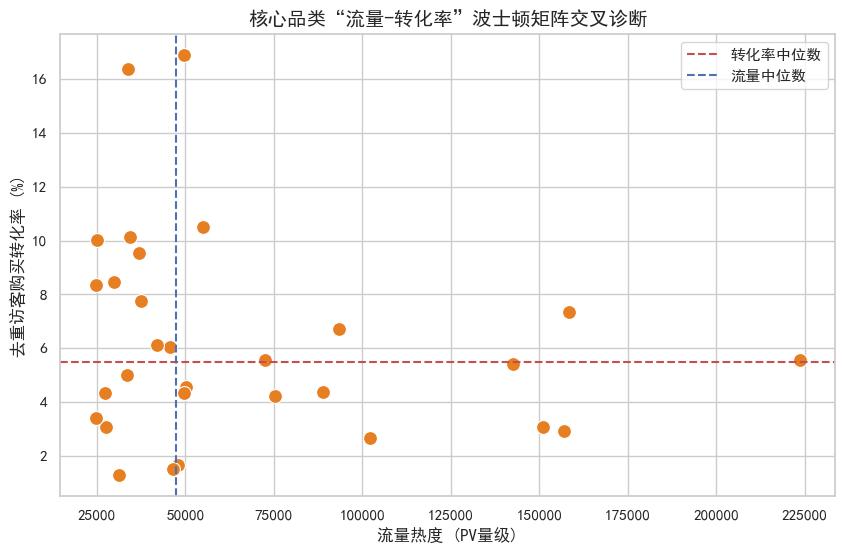

In [6]:
# 品类核心指标：点击量、总访客数、购买访客数
category_perf = df_sample.groupby('category_id').agg(
    pv_count=('behavior_type', lambda x: (x == 'pv').sum()),
    total_users=('user_id', 'nunique'),
    buyers=('user_id', lambda x: x[df_sample.loc[x.index, 'behavior_type'] == 'buy'].nunique())
).reset_index()

# 转化率 = 购买访客数 / 总访客数
category_perf['conversion_rate'] = (category_perf['buyers'] / category_perf['total_users'] * 100).round(2)

# 选取流量前30的品类进行诊断
top_categories = category_perf.sort_values(by='pv_count', ascending=False).head(30)

# 绘图
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pv_count', y='conversion_rate', data=top_categories, s=100, color='#e67e22')

# 参考线划分四象限
plt.axhline(top_categories['conversion_rate'].median(), color='r', linestyle='--', label='转化率中位数')
plt.axvline(top_categories['pv_count'].median(), color='b', linestyle='--', label='流量中位数')

plt.title('核心品类“流量-转化率”波士顿矩阵交叉诊断', fontsize=14, fontweight='bold')
plt.xlabel('流量热度 (PV量级)')
plt.ylabel('去重访客购买转化率 (%)')
plt.legend()

plt.savefig(os.path.join(OUTPUTS_DIR, '07_category_bcg_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

3.品类交叉销售分析
基于用户同一天内购买不同品类的行为，计算品类间的共现次数，
生成交叉销售热力图，用于捆绑推荐与营销活动设计。

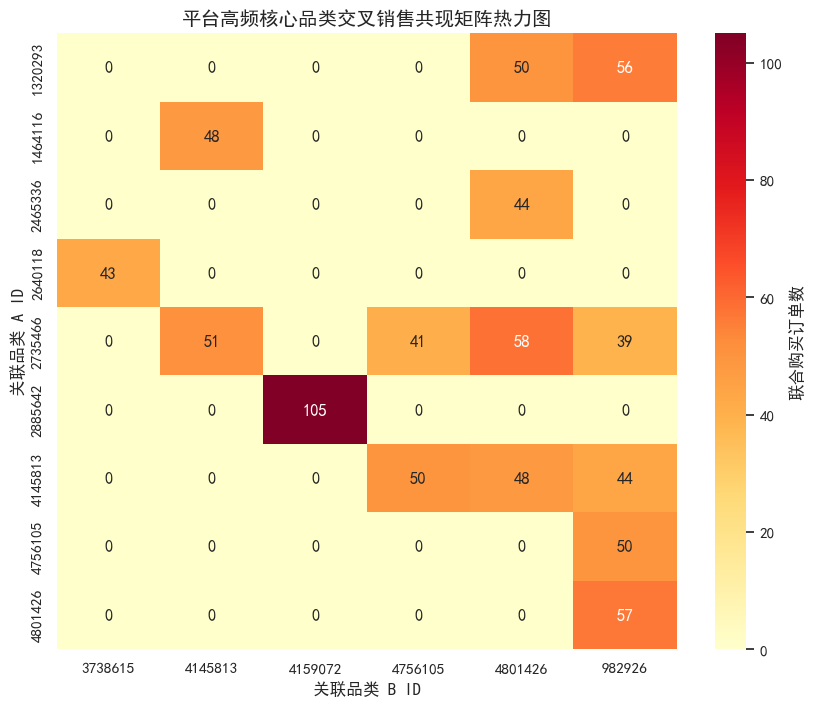

In [4]:
# 获取购买事实表：用户-日期-品类，去重表示当天在该品类有购买行为
df_buy_fact = df_sample[df_sample['behavior_type'] == 'buy'][['user_id', 'date', 'category_id']].drop_duplicates()

# 选取购买热度最高的前50个品类
top_50_cats = df_buy_fact['category_id'].value_counts().head(50).index
df_buy_fact_filtered = df_buy_fact[df_buy_fact['category_id'].isin(top_50_cats)]

# 品类自关联计算：：同一用户同一天购买的两个不同品类
basket_merged = pd.merge(df_buy_fact_filtered, df_buy_fact_filtered, on=['user_id', 'date'])
basket_rules = basket_merged[basket_merged['category_id_x'] < basket_merged['category_id_y']]

# 统计品类对的共现次数
market_basket = basket_rules.groupby(['category_id_x', 'category_id_y']).size().reset_index(name='co_occurrence_count')
market_basket = market_basket.sort_values(by='co_occurrence_count', ascending=False).head(15)

# 转换为矩阵并绘制热力图
pivot_basket = market_basket.pivot(index='category_id_x', columns='category_id_y', values='co_occurrence_count').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_basket, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '联合购买订单数'})
plt.title('平台高频核心品类交叉销售共现矩阵热力图', fontsize=14, fontweight='bold')
plt.xlabel('关联品类 B ID')
plt.ylabel('关联品类 A ID')

plt.savefig(os.path.join(OUTPUTS_DIR, '08_cross_selling_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()